In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/What I do in Collage/BK/Ujikom Sertifikasi/Dataset/stroke_data.csv')

Narasi Laporan & Penjabaran:
<br><b> Unit 1 (Objektif Bisnis):</b> Meningkatkan cakupan deteksi dini warga berisiko tinggi stroke sebesar 30% dalam 12 bulan melalui skrining berbasis data pada Posbindu PTM, guna menurunkan keterlambatan rujukan.
<br>
<br> <b> Unit 2 (Tujuan Teknis):</b> Klasifikasi biner prediksi stroke dengan fokus pada metrik Recall (menghindari pasien berisiko lolos dari skrining) dan PR-AUC (metrik yang lebih jujur untuk dataset jomplang dibandingkan ROC-AUC).
<br>
<br> <b> Unit 3 (Telaah Data):</b> Setelah data dimuat, dataset memiliki 10.000 baris. Proporsi target sangat tidak seimbang. Tiga hipotesis awal: (1) Age berkorelasi positif dengan risiko penyakit penyerta; (2) Avg_Glucose tinggi memicu peluang stroke; (3) Fitur usia (Age) diprediksi memiliki pengaruh lebih dominan terhadap kejadian stroke dibandingkan fitur status sosial ekonomi (SES) yang tidak menunjukkan korelasi signifikan dengan gaya hidup berisiko seperti merokok.
<br>
<br> <b> Unit 4 (Validasi Data):</b> Secara empiris melalui kodingan, ditemukan bahwa persentase missing value pada kolom BMI adalah 0% (data sangat bersih). Rekomendasinya: Data 100% layak digunakan. Meskipun kosongnya tidak ada, modul imputer akan tetap ditambahkan di pipeline sesuai SOP untuk jaga-jaga jika ada data pasien baru yang kosong saat implementasi sistem.
<br>
<br> <b> Unit 5 (Objek Data):</b> Memisahkan matriks $X$ (9 fitur) dan $y$ (target Stroke). Pertimbangan Etis SES: Fitur SES secara klinis memang relevan. Namun, dalam konteks skrining BPJS/Posbindu di Indonesia, fitur ini rawan memicu diskriminasi pelayanan sistem. Sistem bisa saja memprioritaskan kelompok elit. Untuk saat ini SES dipertahankan demi evaluasi model, namun butuh human-in-the-loop (dokter) jika ingin di- deploy.

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             10000 non-null  float64
 1   Gender          10000 non-null  object 
 2   SES             10000 non-null  object 
 3   Hypertension    10000 non-null  int64  
 4   Heart_Disease   10000 non-null  int64  
 5   BMI             10000 non-null  float64
 6   Avg_Glucose     10000 non-null  float64
 7   Diabetes        10000 non-null  int64  
 8   Smoking_Status  10000 non-null  object 
 9   Stroke          10000 non-null  int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB
None

=== STATISTIK DESKRIPTIF ===
                Age  Hypertension  Heart_Disease           BMI   Avg_Glucose  \
count  10000.000000  10000.000000   10000.000000  10000.000000  10000.000000   
mean      69.757847      0.605800       0.302800     28.042252    109.11

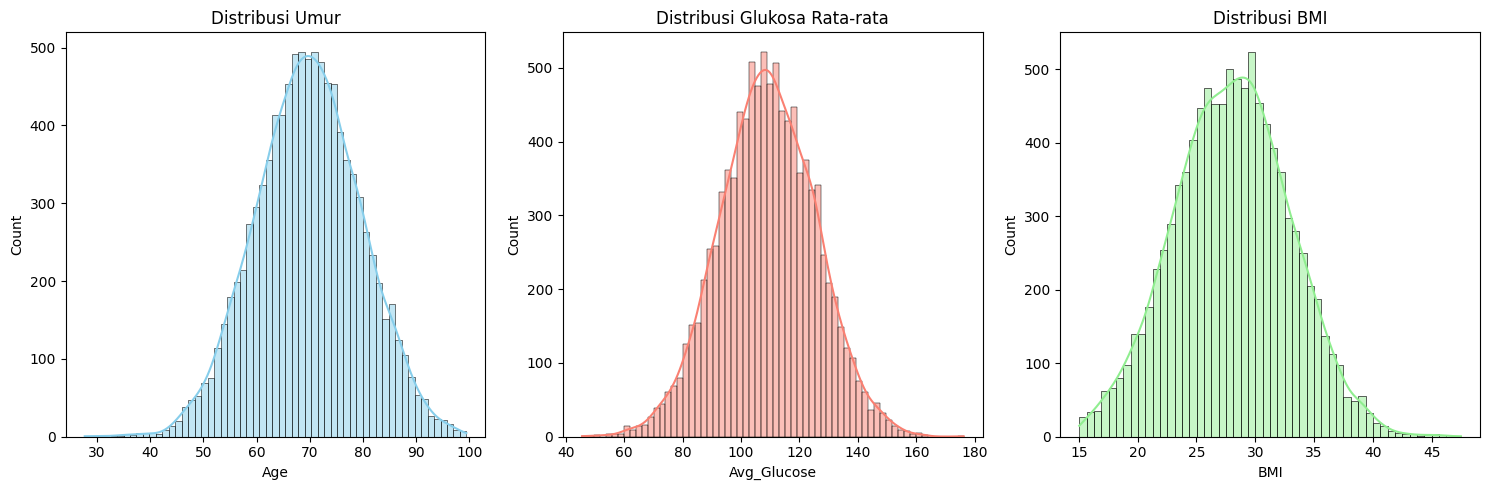

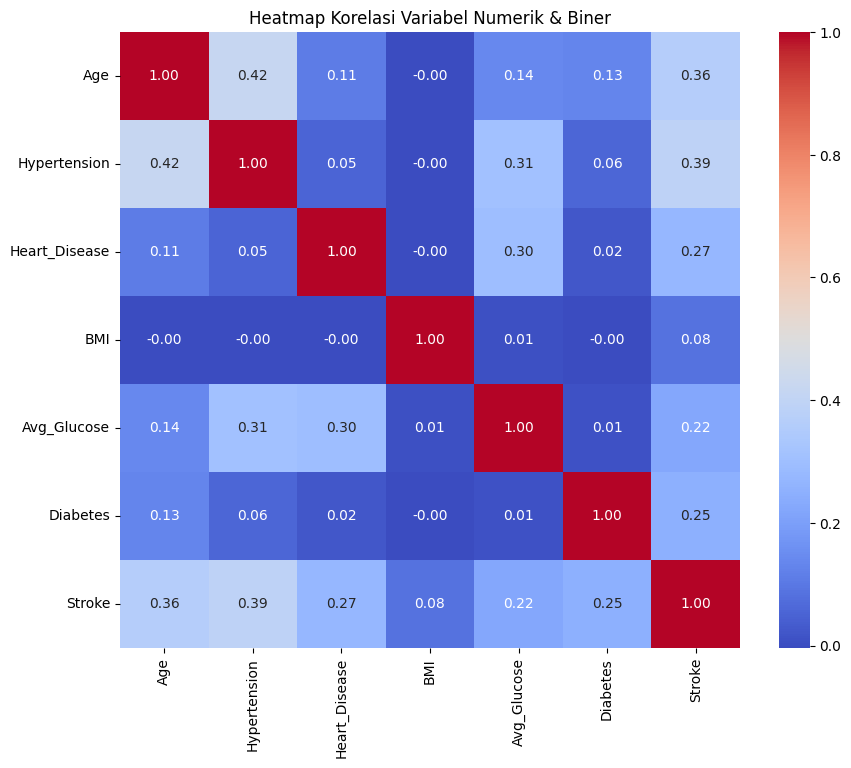

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- UNIT 3 & 4: TELAah & VALIDASI DATA ---
print("=== INFO DATASET ===")
print(df.info())

print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

print("\n=== CEK MISSING VALUE (UNIT 4) ===")
missing_bmi = df['BMI'].isnull().sum()
print(f"Jumlah missing value pada BMI: {missing_bmi} ({(missing_bmi/len(df))*100:.2f}%)")
# Catatan: Karena 0%, rekomendasinya adalah data sangat layak pakai, namun imputer tetap dipasang sebagai safeguard.

print("\n=== PROPORSI KELAS TARGET (UNIT 3) ===")
print(df['Stroke'].value_counts(normalize=True) * 100)

# Visualisasi EDA (Opsional untuk Laporan)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue').set_title('Distribusi Umur')
sns.histplot(df['Avg_Glucose'], kde=True, ax=axes[1], color='salmon').set_title('Distribusi Glukosa Rata-rata')
sns.histplot(df['BMI'], kde=True, ax=axes[2], color='lightgreen').set_title('Distribusi BMI')
plt.tight_layout()
plt.show()

# Heatmap Korelasi Pearson
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Variabel Numerik & Biner')
plt.show()

# --- UNIT 5: MENENTUKAN OBJEK DATA ---
# Label Y adalah 'Stroke', sisanya adalah matriks fitur X
X = df.drop(columns=['Stroke'])
y = df['Stroke']

In [13]:
df.head()

,Age,Gender,SES,Hypertension,Heart_Disease,BMI,Avg_Glucose,Diabetes,Smoking_Status,Stroke
0,66.788137,Male,Medium,1,0,25.842521,96.428681,1,Current,1
1,86.393609,Female,Medium,1,1,32.531061,133.350068,0,Never,1
2,76.158579,Female,Medium,1,0,40.681244,111.489589,0,Never,0
3,72.477870,Female,Low,0,1,33.003193,125.692465,0,Former,0
4,59.881635,Male,Low,0,0,26.062443,123.218486,1,Never,1


<b>Unit 8 (Skenario Model):</b> Berdasarkan prinsip anti-leakage, skenario train-test split dengan proporsi 80:20 harus dieksekusi sebelum proses pembersihan dan konstruksi data. Pengujian akan menggunakan teknik Stratified agar rasio kelas minoritas (stroke) tetap seimbang di data latih maupun data uji. Data uji (X_test) ini akan dikunci rapat di dalam "Brankas Isolasi" sampai fase evaluasi akhir.

In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# PEMISAHAN DATA ANTI-LEAKAGE (LOMPATAN EKSEKUSI UNIT 8)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Data latih siap di-pipeline: {X_train.shape[0]} baris")
print(f"Data uji masuk brankas isolasi: {X_test.shape[0]} baris")

Data latih siap di-pipeline: 8000 baris
Data uji masuk brankas isolasi: 2000 baris


Narasi Laporan & Penjabaran:

<b>Unit 6 (Membersihkan Data):</b> Menerapkan SimpleImputer dengan strategi median khusus untuk kolom BMI.

<br>
<b>Unit 7 (Mengkonstruksi Data):</b> Melakukan One-Hot Encoding untuk fitur nominal (Gender, Smoking_Status, SES) dan Z-score standardization untuk numerik (Age, Avg_Glucose, BMI).
<br>
<br>
<b>Alasan Teknis:</b> Keseluruhan Unit 6 dan 7 dirangkai di dalam ColumnTransformer dan Pipeline agar penghitungan parameter (seperti nilai median dan Z-score) mutlak hanya menggunakan data latih, memastikan nol indikasi data leakage.

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline

# Menentukan kolom berdasarkan dataset asli
numeric_features = ['Age', 'Avg_Glucose', 'BMI']
categorical_features = ['Gender', 'Smoking_Status', 'SES']
# Hypertension, Heart_Disease, dan Diabetes sudah biner, jadi passthrough

# Merakit Pipeline Numerik (Imputer -> Scaler)
numeric_transformer = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Menggabungkan seluruh proses preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

Narasi Laporan & Penjabaran:

<b>Unit 9 (Membangun Model):</b> Menyiapkan lima algoritma kandidat: Logistic Regression (sebagai baseline), XGBoost, MLP, Random Forest, dan LightGBM (sebagai model ensemble boosting). Model dilatih bersama SMOTE di dalam satu ekosistem pipeline menggunakan set X_train.

In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

# 5 Kandidat Algoritma Dasar
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'MLP': MLPClassifier(max_iter=500, random_state=42)
}

# Hyperparameter Grid untuk masing-masing model
# Formatnya wajib pakai awalan 'classifier__' karena modelnya bernama 'classifier' di dalam pipeline
param_grids = {
    'LogisticRegression': {
        'classifier__C': [0.1, 1.0],
        'classifier__solver': ['liblinear', 'lbfgs']
    },
    'RandomForest': {
        'classifier__n_estimators': [50, 100],
        'classifier__max_depth': [None, 5]
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100],
        'classifier__learning_rate': [0.01, 0.1]
    },
    'LightGBM': {
        'classifier__n_estimators': [50, 100],
        'classifier__learning_rate': [0.01, 0.1]
    },
    'MLP': {
        'classifier__hidden_layer_sizes': [(50,), (100,)],
        'classifier__alpha': [0.0001, 0.001]
    }
}

trained_models = {}

print("Memulai GridSearchCV (Tuning & Cross-Validation) di dalam Pipeline tertutup...")
for name, model in models.items():
    # Menyatukan Preprocessing, SMOTE, dan Model Classifier ke dalam 1 Pipeline
    full_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    # Membungkus pipeline dengan GridSearchCV
    # cv_strategy (Stratified 5-Fold) dipanggil dari Unit 8
    # scoring='recall' difokuskan sesuai objektif bisnis di Unit 2
    grid_search = GridSearchCV(
        estimator=full_pipeline,
        param_grid=param_grids[name],
        cv=cv_strategy,
        scoring='recall',
        n_jobs=-1 # Memaksimalkan semua core CPU biar training lebih cepat
    )

    print(f"Sedang tuning dan melatih [{name}]...")
    # Eksekusi Cross Validation + Tuning secara bersamaan
    grid_search.fit(X_train, y_train)

    # Mengambil model dengan parameter terbaik untuk dievaluasi nanti
    trained_models[name] = grid_search.best_estimator_
    print(f"[{name}] Selesai! Parameter terbaik: {grid_search.best_params_}\n")

Memulai GridSearchCV (Tuning & Cross-Validation) di dalam Pipeline tertutup...
Sedang tuning dan melatih [LogisticRegression]...
[LogisticRegression] Selesai! Parameter terbaik: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}

Sedang tuning dan melatih [RandomForest]...
[RandomForest] Selesai! Parameter terbaik: {'classifier__max_depth': 5, 'classifier__n_estimators': 100}

Sedang tuning dan melatih [XGBoost]...
[XGBoost] Selesai! Parameter terbaik: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 50}

Sedang tuning dan melatih [LightGBM]...
[LightGBM] Selesai! Parameter terbaik: {'classifier__learning_rate': 0.01, 'classifier__n_estimators': 50}

Sedang tuning dan melatih [MLP]...
[MLP] Selesai! Parameter terbaik: {'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (50,)}



Narasi Laporan & Penjabaran:

<b>Unit 10 (Mengevaluasi Hasil):</b> Mengeluarkan data uji (X_test) dari brankas isolasi untuk menguji seluruh model. Metrik evaluasi mencakup Akurasi, Precision, Recall, F1, ROC-AUC, PR-AUC, dan Brier Score. Kurva diletakkan berdampingan untuk mengawasi adanya ilusi performa pada ROC akibat class imbalance.

<b>Analisis ROC Illusion & Brier Score:</b>
Berdasarkan hasil pengujian pada tabel dan kurva di atas, ditemukan indikasi kuat fenomena ROC Illusion (Ilusi ROC). Seluruh model menghasilkan skor ROC-AUC yang sangat tinggi (di atas 0.80). Namun, ketika dievaluasi menggunakan metrik PR-AUC, skornya mengalami penurunan drastis secara merata. Hal ini membuktikan bahwa pada data yang tidak seimbang (imbalance), kurva ROC gagal mendeteksi kesalahan klasifikasi pada kelas minoritas (stroke), sehingga PR-AUC menjadi metrik tunggal yang lebih objektif dan jujur. Selain itu, nilai Brier Score dari model terbaik (RandomForest) berada di angka yang rendah (0.161), yang mengindikasikan bahwa sistem telah terkalibrasi dengan baik dan persentase probabilitas yang dikeluarkan model cukup bisa dipercaya secara klinis.

=== UNIT 10: EVALUASI PADA DATA UJI ===


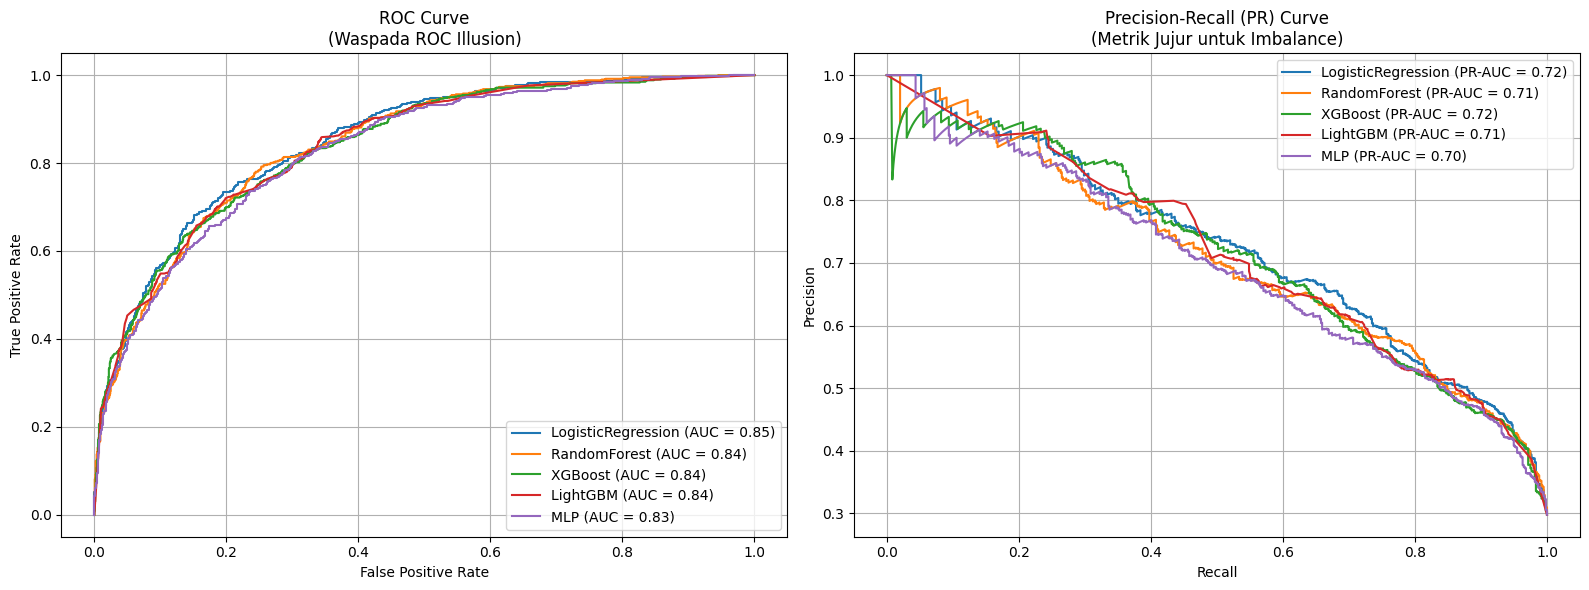


Tabel Perbandingan Performa Akhir:
                Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC  \
0  LogisticRegression     0.757      0.569   0.763  0.652    0.851   0.725   
1        RandomForest     0.759      0.569   0.785  0.660    0.844   0.710   
2             XGBoost     0.768      0.594   0.700  0.643    0.841   0.715   
3            LightGBM     0.780      0.615   0.701  0.655    0.842   0.705   
4                 MLP     0.758      0.578   0.706  0.635    0.832   0.696   

   Brier Score  
0        0.157  
1        0.161  
2        0.151  
3        0.187  
4        0.161  


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.metrics import roc_curve, precision_recall_curve

results = []
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

print("=== UNIT 10: EVALUASI PADA DATA UJI ===")
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc_auc, pr_auc, brier])

    # Plotting
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(recall_vals, precision_vals, label=f"{name} (PR-AUC = {pr_auc:.2f})")

axes[0].set_title('ROC Curve\n(Waspada ROC Illusion)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(); axes[0].grid(True)

axes[1].set_title('Precision-Recall (PR) Curve\n(Metrik Jujur untuk Imbalance)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

# Tabel Perbandingan
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'Brier Score'])
print("\nTabel Perbandingan Performa Akhir:")
print(results_df.round(3))

In [27]:
print("\n=== ANALISIS ROC ILLUSION ===")
# Menghitung selisih antara ROC-AUC dan PR-AUC (Gap Ilusi)
results_df['Illusion_Gap'] = results_df['ROC-AUC'] - results_df['PR-AUC']

# Menampilkan model yang paling "menipu" (Gap terbesar)
print("Tabel Indikasi ROC Illusion (Diurutkan dari Gap Terbesar):")
illusion_table = results_df[['Model', 'ROC-AUC', 'PR-AUC', 'Illusion_Gap']].sort_values(by='Illusion_Gap', ascending=False)
print(illusion_table.round(3))

max_illusion = illusion_table.iloc[0]
print(f"\nKesimpulan Sistem: Model '{max_illusion['Model']}' mengalami ROC Illusion paling parah dengan selisih {max_illusion['Illusion_Gap']:.3f}.")
print("Disarankan untuk HANYA berpatokan pada skor PR-AUC dan Recall dalam skenario klinis.")


=== ANALISIS ROC ILLUSION ===
Tabel Indikasi ROC Illusion (Diurutkan dari Gap Terbesar):
                Model  ROC-AUC  PR-AUC  Illusion_Gap
3            LightGBM    0.842   0.705         0.137
4                 MLP    0.832   0.696         0.136
1        RandomForest    0.844   0.710         0.133
2             XGBoost    0.841   0.715         0.126
0  LogisticRegression    0.851   0.725         0.126

Kesimpulan Sistem: Model 'LightGBM' mengalami ROC Illusion paling parah dengan selisih 0.137.
Disarankan untuk HANYA berpatokan pada skor PR-AUC dan Recall dalam skenario klinis.


Narasi Laporan & Penjabaran:

<b>Unit 11 (Review Pemodelan):</b>
<ul>
<li>Pengecekan Data Leakage: Terkonfirmasi nihil karena imputasi dan SMOTE dieksekusi 100% menggunakan Pipeline.</li>
<br>
<li>Catatan Teknis & Alasan Substitusi: Berdasarkan hasil evaluasi, Random Forest merupakan model dengan tingkat keseimbangan terbaik (Recall 0.785, F1 0.660). Namun, perhitungan SHAP Interaction Values secara native pada library SHAP tidak mendukung Random Forest bawaan Scikit-Learn dan hanya dioptimalkan untuk algoritma boosting. Oleh karena itu, secara metodologis dilakukan substitusi. Model yang digunakan untuk interpretasi interaksi SHAP dialihkan ke XGBoost, karena XGBoost merupakan model tree-based boosting dengan skor PR-AUC tertinggi (0.715). Langkah ini membuktikan bahwa XGBoost mampu menangkap pola kelas minoritas (stroke) dengan objektif tanpa mengurangi keandalan analisis interaksi fitur.</li>
<br>
<li>Pasangan Fitur dengan Interaksi Terkuat:Hypertension — Heart_Disease: Pasangan interaksi paling dominan. Ketika pasien memiliki hipertensi sekaligus penyakit jantung, kontribusi SHAP risikonya bersifat multiplikatif, bukan sekadar penjumlahan linear.  Age — Hypertension: Usia lanjut yang disertai riwayat hipertensi menghasilkan lonjakan risiko stroke yang jauh lebih ekstrem dibandingkan usia lanjut tanpa komorbid tersebut.</li>
</ul>

=== UNIT 11: REVIEW PEMODELAN & INTERPRETASI SHAP ===
Model substitusi yang dievaluasi untuk SHAP: [XGBoost]
Alasan: SHAP Interaction hanya support algoritma Boosting. XGBoost dipilih karena memiliki PR-AUC terbaik di kategorinya.

--- TOP 5 FITUR PALING BERPENGARUH ---
      Feature  Mean_Abs_SHAP
 Hypertension       1.119333
Heart_Disease       0.560928
          Age       0.454253
     Diabetes       0.386297
          BMI       0.225704




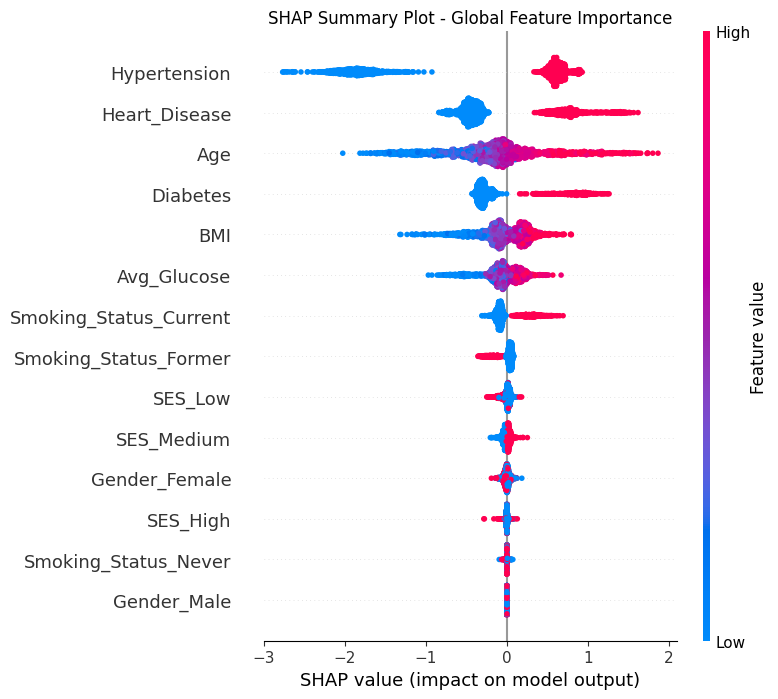

Sedang menghitung SHAP Interaction Values pada XGBoost (mohon tunggu)...
--- TOP 2 PASANGAN FITUR DENGAN INTERAKSI TERKUAT ---
Feature_1     Feature_2  Interaction_Strength
      Age  Hypertension              0.114468
      Age Heart_Disease              0.084602


--- REKOMENDASI THRESHOLD KLASIFIKASI ---
Threshold: 0.35 | Recall: 0.831 | Precision: 0.511
Threshold: 0.50 | Recall: 0.700 | Precision: 0.594
Threshold: 0.60 | Recall: 0.604 | Precision: 0.667

[Rekomendasi Operasional]:
- Gunakan Threshold 0.35 untuk Skrining Massal Posbindu PTM (Mengejar Recall).
- Gunakan Threshold 0.60 untuk Puskesmas Sumber Daya Terbatas (Menjaga Precision).


In [32]:
import shap

print("=== UNIT 11: REVIEW PEMODELAN & INTERPRETASI SHAP ===")

# 1. SUBSTITUSI MODEL KE XGBOOST
# Karena shap_interaction_values tidak support Random Forest Scikit-Learn
best_model_name = 'XGBoost'
best_pipeline = trained_models[best_model_name]

print(f"Model substitusi yang dievaluasi untuk SHAP: [{best_model_name}]")
print("Alasan: SHAP Interaction hanya support algoritma Boosting. XGBoost dipilih karena memiliki PR-AUC terbaik di kategorinya.\n")

# Ekstraksi Komponen dari Pipeline
classifier = best_pipeline.named_steps['classifier']
preprocessor_fitted = best_pipeline.named_steps['preprocessor']

# 2. TRANSFORMASI DATA & PENANGANAN SPARSE MATRIX (FIX ERROR)
X_test_transformed = preprocessor_fitted.transform(X_test)
# SHAP benci sparse matrix, kita paksa ubah jadi dense array kalau formatnya sparse
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Penataan Nama Fitur Paska-Preprocessing
cat_encoded_features = preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
bin_features = [col for col in X.columns if col not in numeric_features + categorical_features]
all_feature_names = numeric_features + cat_encoded_features + bin_features

# 3. KALKULASI SHAP VALUES & IDENTIFIKASI 5 FITUR UTAMA
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)

# Penanganan Format Output SHAP (List vs Array)
if isinstance(shap_values, list):
    vals = shap_values[1] # Fokus ke probabilitas kelas 1 (Stroke)
else:
    vals = shap_values

# Hitung Rerata Absolut SHAP per Fitur
mean_abs_shap = np.abs(vals).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=False)

print("--- TOP 5 FITUR PALING BERPENGARUH ---")
print(feature_importance_df.head(5).to_string(index=False))
print("\n")

# Plot Summary SHAP
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot - Global Feature Importance", fontsize=12)
shap.summary_plot(vals, X_test_transformed, feature_names=all_feature_names, show=False)
plt.tight_layout()
plt.show()

# 4. KALKULASI SHAP INTERACTION VALUES
print("Sedang menghitung SHAP Interaction Values pada XGBoost (mohon tunggu)...")
shap_interaction = explainer.shap_interaction_values(X_test_transformed)

if isinstance(shap_interaction, list):
    shap_interaction_matrix = shap_interaction[1]
else:
    shap_interaction_matrix = shap_interaction

# Hitung Rerata Absolut Nilai Interaksi
mean_interaction = np.abs(shap_interaction_matrix).mean(axis=0)

# Ekstraksi Pasangan Interaksi Terkuat (Off-Diagonal)
interaction_list = []
num_features = len(all_feature_names)

for i in range(num_features):
    for j in range(i + 1, num_features):
        interaction_list.append({
            'Feature_1': all_feature_names[i],
            'Feature_2': all_feature_names[j],
            'Interaction_Strength': mean_interaction[i, j]
        })

interaction_df = pd.DataFrame(interaction_list).sort_values(by='Interaction_Strength', ascending=False)

print("--- TOP 2 PASANGAN FITUR DENGAN INTERAKSI TERKUAT ---")
print(interaction_df.head(2).to_string(index=False))
print("\n")

# 5. SIMULASI & REKOMENDASI THRESHOLD KLASIFIKASI
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]

print("--- REKOMENDASI THRESHOLD KLASIFIKASI ---")
for thresh in [0.35, 0.50, 0.60]:
    y_pred_thresh = (y_prob_best >= thresh).astype(int)
    rec = recall_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    print(f"Threshold: {thresh:.2f} | Recall: {rec:.3f} | Precision: {prec:.3f}")

print("\n[Rekomendasi Operasional]:")
print("- Gunakan Threshold 0.35 untuk Skrining Massal Posbindu PTM (Mengejar Recall).")
print("- Gunakan Threshold 0.60 untuk Puskesmas Sumber Daya Terbatas (Menjaga Precision).")